In [1]:
import numpy as np
import pandas as pd

# 회귀분석의 기초
* 가장 훌륭한 예측선 그리기

**선형회귀**와 **로지스틱 회귀**
* 딥러닝의 가장 말단에서 이루어지는 기본적인 두 가지 계산 원리
* 가장 훌륭한 예측선 : 선형회귀분석을 이용한 모델

## 최소제곱법

In [11]:
# 공부한 시간과 점수를 각각 X, y 변수에 넣기
# 공부한 시간
X = np.array([2, 4, 6, 8])
# 점수
y = np.array([81, 93, 91, 97])

# X, y의 평균 구하기
X_mean = np.mean(X)
y_mean = np.mean(y)
print('공부한 시간의 평균 :', X_mean, '점수의 평균 :', y_mean)

# 기울기 공식 : y = wx + b (w : weight (가중치) / b : bias (편차))
# 최소 제곱법 분모 만들기
divisor = sum([(i - X_mean) ** 2 for i in X])

# 최소 제곱법 분자 만들기
def top(x, x_mean, y, y_mean):
    d = 0
    for i in range(len(x)):
        d += (x[i] - x_mean) * (y[i] - y_mean)
    return d

dividend = top(X, X_mean, y, y_mean)

print('분모 :', divisor)
print('분자 :', dividend)

# 평균 제곱 오차 구하기
w = dividend / divisor

# b
b = y_mean - (X_mean * w)

print('가중치 :', w)
print('bias :', b)
print('가장 훌륭한 예측선\n>> y = %.1fx + %d' %(w, b))

공부한 시간의 평균 : 5.0 점수의 평균 : 90.5
분모 : 20.0
분자 : 46.0
가중치 : 2.3
bias : 79.0
가장 훌륭한 예측선
>> y = 2.3x + 79


In [13]:
# 예측 함수 (y_pred = wx + b)
def predict(x):
    return w * x + b

# 예측값이 들어갈 빈 리스트 생성
result = []

for i in range(len(X)):
    result.append(predict(X[i]))
    print('>> 공부한 시간 : %.2f <<\n실제 점수 : %.2f\n예측 점수 : %.2f' %(X[i], y[i], predict(X[i])))

>> 공부한 시간 : 2.00 <<
실제 점수 : 81.00
예측 점수 : 83.60
>> 공부한 시간 : 4.00 <<
실제 점수 : 93.00
예측 점수 : 88.20
>> 공부한 시간 : 6.00 <<
실제 점수 : 91.00
예측 점수 : 92.80
>> 공부한 시간 : 8.00 <<
실제 점수 : 97.00
예측 점수 : 97.40


In [14]:
# 평균제곱오차 함수 이용, 각 y값 대입 >> 최종값 구하기
n = len(X)

def mse(y, y_pred):
    return (1/n) * sum((y - y_pred) ** 2)

# 평균제곱오차 출력
print('MSE :', str(mse(y, result)))

MSE : 8.299999999999985


---

# Linear Regression

In [15]:
import matplotlib.pyplot as plt

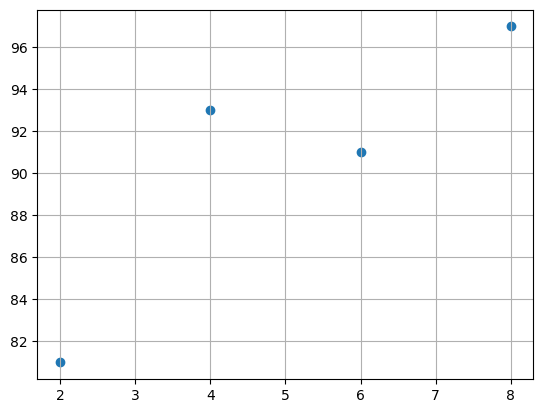

In [16]:
# input 값은 무조건 배열이다 !!
# 공부한 시간 (독립변수)
X = np.array([2, 4, 6, 8])
# 시험성적 (종속변수)
y = np.array([81, 93, 91, 97])

plt.scatter(X, y)
plt.grid()
plt.show()

In [22]:
# 회귀식 만들기
# 가중치 w, 편향 b
# 초기화
w = 0
b = 0

# 학습률 (learning rate)
l = 0.03

# 반복 횟수
epochs = 2001

## 경사하강법 (sgd)
# 편미분해서 오차가 가장 적은 weight를 찾는 방법
n = len(X)

# epochs수 만큼 반복하기
for i in range(epochs):
    # 단순 선형 회귀식
    y_pred = w * X + b
    error = y - y_pred

    # w(가중치), b(편향) 편미분
    w_diff = (2/n) * sum((-X) * error) # 오차(비용)함수를 w로 편미분
    b_diff = (2/n) * sum(-error) # 오차(비용)함수를 b로 편미분

    # w_diff에 학습률을 곱해서 기존의 w를 업데이트
    w = w - (l * w_diff)
    # b_diff에 학습률을 곱해서 기존의 b를 업데이트
    b = b - (l * b_diff)

    if i % 100 == 0:
        print('>> epoch %.f\nweight : %.4f, bias : %.4f\n' %(i, w, b))

>> epoch 0
weight : 27.8400, bias : 5.4300

>> epoch 100
weight : 7.0739, bias : 50.5117

>> epoch 200
weight : 4.0960, bias : 68.2822

>> epoch 300
weight : 2.9757, bias : 74.9678

>> epoch 400
weight : 2.5542, bias : 77.4830

>> epoch 500
weight : 2.3956, bias : 78.4293

>> epoch 600
weight : 2.3360, bias : 78.7853

>> epoch 700
weight : 2.3135, bias : 78.9192

>> epoch 800
weight : 2.3051, bias : 78.9696

>> epoch 900
weight : 2.3019, bias : 78.9886

>> epoch 1000
weight : 2.3007, bias : 78.9957

>> epoch 1100
weight : 2.3003, bias : 78.9984

>> epoch 1200
weight : 2.3001, bias : 78.9994

>> epoch 1300
weight : 2.3000, bias : 78.9998

>> epoch 1400
weight : 2.3000, bias : 78.9999

>> epoch 1500
weight : 2.3000, bias : 79.0000

>> epoch 1600
weight : 2.3000, bias : 79.0000

>> epoch 1700
weight : 2.3000, bias : 79.0000

>> epoch 1800
weight : 2.3000, bias : 79.0000

>> epoch 1900
weight : 2.3000, bias : 79.0000

>> epoch 2000
weight : 2.3000, bias : 79.0000



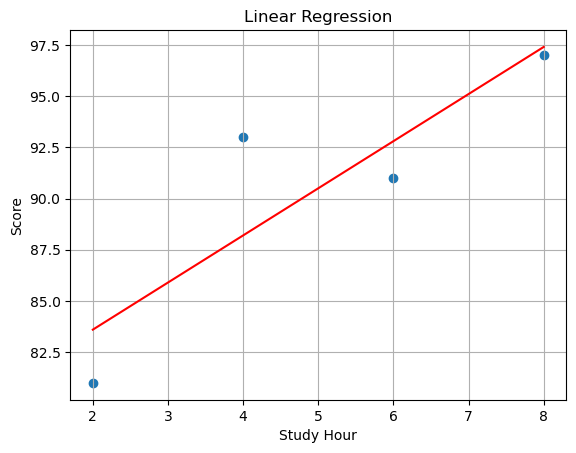

In [24]:
y_pred = w * X + b

plt.scatter(X, y)
plt.plot(X, y_pred, 'r')
plt.xlabel('Study Hour')
plt.ylabel('Score')
plt.title('Linear Regression')
plt.grid()
plt.show()

# 다중 선형회귀

In [26]:
X1 = np.array([2, 4, 6, 8])
X2 = np.array([0 ,4, 2, 3])
y = np.array([81, 93, 91, 97])

# 데이터 분포 확인
# fig = plt.figure()

In [27]:
# 변수 설정
# 초기화
w1 = 0
w2 = 0
b = 0

# 학습률 설정 (임의로 정함)
l = 0.01

# 몇 번 반복할지 결정
epochs = 2001

# 경사하강법
n = len(X1)

for i in range(epochs):
    y_pred = w1 * X1 + w2 * X2 + b
    error = y - y_pred

    # 편미분
    w1_diff = (2/n) * sum((-X1) * error)
    w2_diff = (2/n) * sum((-X2) * error)
    b_diff = (2/n) * sum(-error)

    # 학습률
    w1 = w1 - l * w1_diff
    w2 = w2 - l * w2_diff
    b = b - l * b_diff

    if i % 100 == 0:
        print('>> epochs %.f\nweight 1 : %.4f, weight 2 : %.4f, bias : %.4f' %(i, w1, w2, b))

>> epochs 0
weight 1 : 9.2800, weight 2 : 4.2250, bias : 1.8100
>> epochs 100
weight 1 : 9.5110, weight 2 : 5.0270, bias : 22.9205
>> epochs 200
weight 1 : 7.3238, weight 2 : 4.2950, bias : 37.8751
>> epochs 300
weight 1 : 5.7381, weight 2 : 3.7489, bias : 48.7589
>> epochs 400
weight 1 : 4.5844, weight 2 : 3.3507, bias : 56.6800
>> epochs 500
weight 1 : 3.7447, weight 2 : 3.0608, bias : 62.4448
>> epochs 600
weight 1 : 3.1337, weight 2 : 2.8498, bias : 66.6404
>> epochs 700
weight 1 : 2.6890, weight 2 : 2.6962, bias : 69.6938
>> epochs 800
weight 1 : 2.3653, weight 2 : 2.5845, bias : 71.9160
>> epochs 900
weight 1 : 2.1297, weight 2 : 2.5032, bias : 73.5333
>> epochs 1000
weight 1 : 1.9583, weight 2 : 2.4440, bias : 74.7103
>> epochs 1100
weight 1 : 1.8336, weight 2 : 2.4009, bias : 75.5670
>> epochs 1200
weight 1 : 1.7428, weight 2 : 2.3695, bias : 76.1904
>> epochs 1300
weight 1 : 1.6767, weight 2 : 2.3467, bias : 76.6441
>> epochs 1400
weight 1 : 1.6286, weight 2 : 2.3301, bias : 7

In [30]:
# 실제 점수와 예측 점수 출력
print('실제 점수 :', y)
print('예측 점수 :', y_pred)

실제 점수 : [81 93 91 97]
예측 점수 : [80.76387645 92.97153922 91.42520875 96.7558749 ]


# Tensorflow 활용, 선형회귀모델

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense # 1차원 배열

In [ ]:
# 데이터 준비
# 공부 시간
X = np.array([2, 4, 6, 8])
# 점수
y = np.array([81, 93, 91, 97])

model = Sequential()

# 출력값, 입력변수, 분석방법 (활성화 함수)
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사하강법 사용하기
# 오차 정도 판단하는 평가 방법 >> mse(평균제곱오차)
model.compile(optimizer='sgd', loss='mse')
# 실행
model.fit(X, y, epochs=2001)

Epoch 1/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step - loss: 6782.1333
Epoch 2/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 1834.2117
Epoch 3/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1102.1049
Epoch 4/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 989.2305
Epoch 5/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 967.3409
Epoch 6/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 958.8489
Epoch 7/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 952.3590
Epoch 8/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 946.1969
Epoch 9/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 940.1168
Epoch 10/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 934.0822
Epoch 11/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 928.0876
Epoch 12/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 922.1320
Epoch 13/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - loss: 916.2148
Epoch 14/2001
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 910.3360
Epoch 15/2001
1/1 ━━━━━━━━━━━━━

In [35]:
# 모델 테스트
hour = 7
prediction = model.predict([hour])

print('%.f 시간 공부 --> 예상점수 : %.2f점' %(hour, prediction))

ValueError: Unrecognized data type: x=[7] (of type <class 'list'>)

In [ ]:
# 다중회귀분석
X = np.array([[2, 0], [4, 4], [6, 2], [8, 3]])
y = np.array([81, 93, 91, 97])

model = Sequential()

# 출력값, 입력변수, 분석방법 (활성화 함수)
model.add(Dense(1, input_dim=1, activation='linear'))

# 오차 수정을 위해 경사하강법 사용하기
# 오차 정도 판단하는 평가 방법 >> mse(평균제곱오차)
model.compile(optimizer='sgd', loss='mse')
# 실행
model.fit(X, y, epochs=2001)

# 모델 테스트
hour = 7
private_class = 4
prediction = model.predict([[hour, private_class]])

print('%.f 시간 공부 & %.f 시간 과외 --> 예상점수 : %.2f점' %(hour, private_class, prediction))